# Civile flussi 2014-2025 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `civile_flussi` (Ministero della Giustizia) via GCS clean parquet.
**Serie**: 2014-2025, 12 anni, distretti e materie.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
GCS = 'gs://dataciviclab-clean/civile_flussi/2025/civile_flussi_2025_clean.parquet'

# Verifica copertura
anni = con.execute(f"SELECT DISTINCT anno FROM read_parquet('{GCS}') ORDER BY anno").fetchdf()
print(f"Anni: {list(anni['anno'])}")


Anni: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [2]:
# 1. Trend nazionale 2014-2025
trend = con.execute(f"""
    SELECT anno,
           CAST(SUM(sopravvenuti) AS BIGINT) AS sopravvenuti,
           CAST(SUM(definiti_totale) AS BIGINT) AS definiti,
           CAST(SUM(pendenti_finali) AS BIGINT) AS pendenti,
           ROUND(CAST(SUM(definiti_totale) AS DOUBLE)
                 / NULLIF(CAST(SUM(sopravvenuti) AS DOUBLE), 0), 3) AS rapporto_ds
    FROM read_parquet('{GCS}')
    GROUP BY anno
    ORDER BY anno
""").fetchdf()

display(trend)

print(f"Backlog: {int(trend[trend['anno']==2014]['pendenti'].values[0]):,} -> {int(trend[trend['anno']==2025]['pendenti'].values[0]):,} = -{((1 - int(trend[trend['anno']==2025]['pendenti'].values[0])/int(trend[trend['anno']==2014]['pendenti'].values[0]))*100):.0f}%")
min_ratio = trend.loc[trend['rapporto_ds'].idxmin()]
print(f"Minimo rapporto D/S: {min_ratio['rapporto_ds']:.3f} nel {int(min_ratio['anno'])}")


,anno,sopravvenuti,definiti,pendenti,rapporto_ds
0,2014,2728755,2849226,3499992,1
1,2015,2487697,2694330,3306301,1
2,2016,2581875,2671132,3227180,1
3,2017,2564650,2672683,3133952,1
4,2018,2567680,2710262,3008064,1
5,2019,2560003,2688292,2887531,1
6,2020,1997290,2045655,2859048,1
7,2021,2243056,2444181,2668447,1
8,2022,2339868,2504880,2516552,1
9,2023,2193857,2382981,2349276,1


Backlog: 3,499,992 -> 2,300,045 = -34%
Minimo rapporto D/S: 0.997 nel 2024


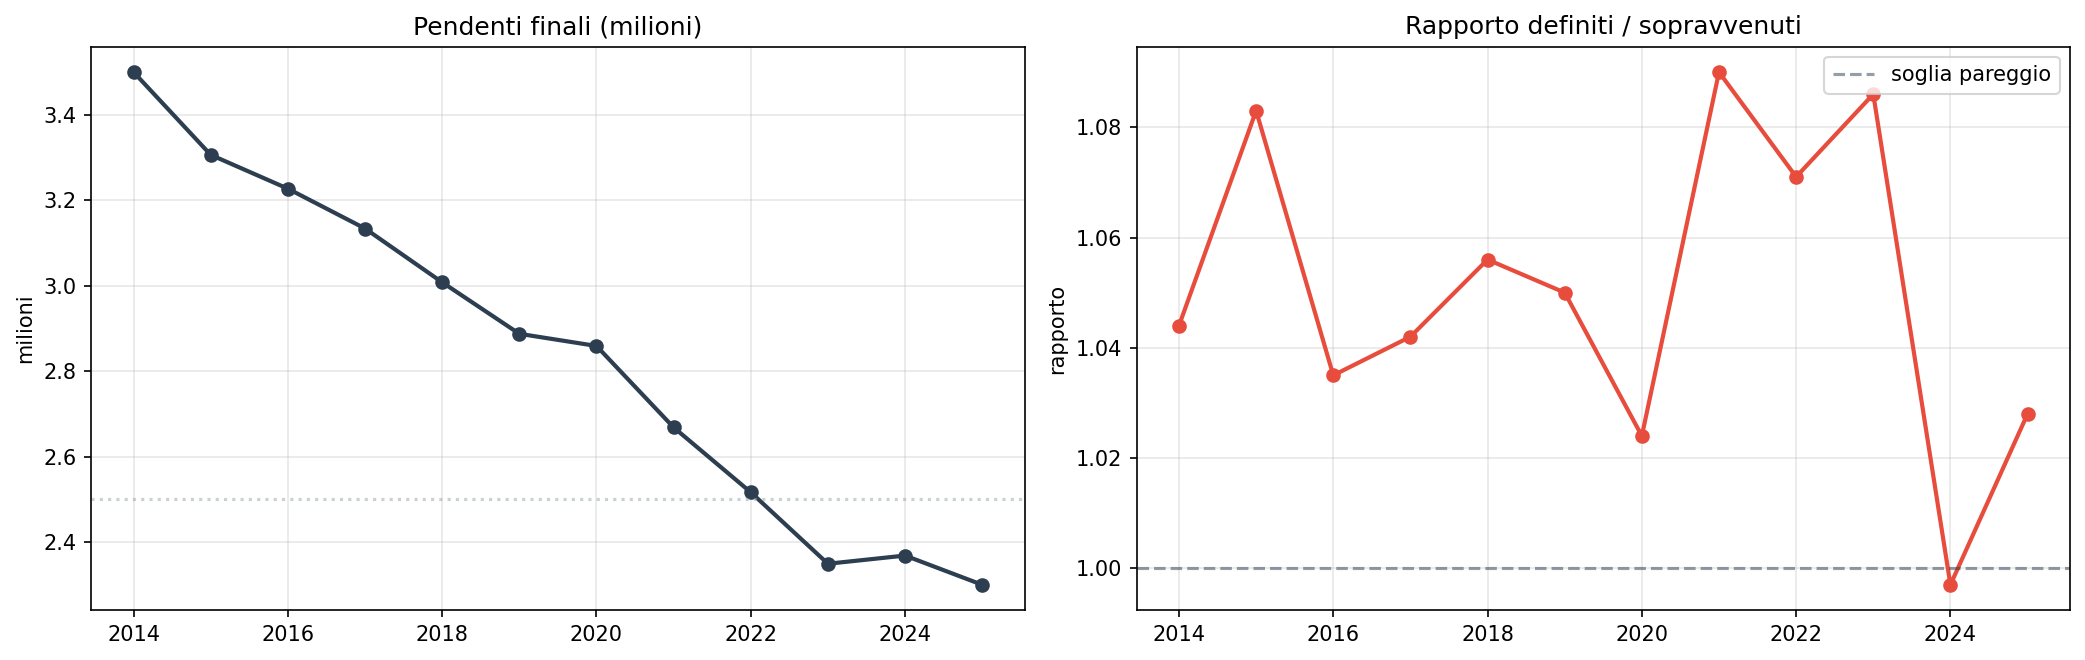

Salvato: figures/civile_trend_nazionale.png


In [3]:
# Grafico trend nazionale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(trend['anno'], trend['pendenti'] / 1e6, marker='o', linewidth=2, color='#2c3e50')
ax1.axhline(y=2.5, color='#95a5a6', linestyle=':', alpha=0.5)
ax1.set_title('Pendenti finali (milioni)', fontsize=12)
ax1.set_ylabel('milioni')
ax1.grid(alpha=0.3)

ax2.plot(trend['anno'], trend['rapporto_ds'], marker='o', linewidth=2, color='#e74c3c')
ax2.axhline(y=1.0, color='#2c3e50', linestyle='--', alpha=0.5, label='soglia pareggio')
ax2.set_title('Rapporto definiti / sopravvenuti', fontsize=12)
ax2.set_ylabel('rapporto')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/civile_trend_nazionale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/civile_trend_nazionale.png')


In [4]:
# 2. Distretti: rapporto D/S 2025
distretti = con.execute(f"""
    SELECT distretto,
           CAST(SUM(sopravvenuti) AS BIGINT) AS sopravvenuti,
           CAST(SUM(definiti_totale) AS BIGINT) AS definiti,
           CAST(SUM(pendenti_finali) AS BIGINT) AS pendenti,
           ROUND(CAST(SUM(definiti_totale) AS DOUBLE)
                 / NULLIF(CAST(SUM(sopravvenuti) AS DOUBLE), 0), 3) AS rapporto_ds
    FROM read_parquet('{GCS}')
    WHERE anno = 2025
    GROUP BY distretto
    ORDER BY rapporto_ds ASC
""").fetchdf()

display(distretti)

print(f"Distretti sotto soglia (<1): {len(distretti[distretti['rapporto_ds'] < 1])} su {len(distretti)}")
print(f"Miglior distretto: {distretti.iloc[-1]['distretto']} ({distretti.iloc[-1]['rapporto_ds']:.3f})")
print(f"Peggior distretto: {distretti.iloc[0]['distretto']} ({distretti.iloc[0]['rapporto_ds']:.3f})")


,distretto,sopravvenuti,definiti,pendenti,rapporto_ds
0,Venezia,148203,139583,143693,1
1,Trieste,50213,47789,40208,1
2,Torino,153131,146343,110979,1
3,Genova,62994,61163,58076,1
4,Firenze,130837,129385,104394,1
5,Bologna,144108,142654,106908,1
6,Milano,199781,200109,164227,1
7,Trento,26537,26635,20925,1
8,Cagliari,57063,57428,80971,1
9,Brescia,97350,98586,71747,1


Distretti sotto soglia (<1): 6 su 26
Miglior distretto: Reggio Calabria (1.156)
Peggior distretto: Venezia (0.942)


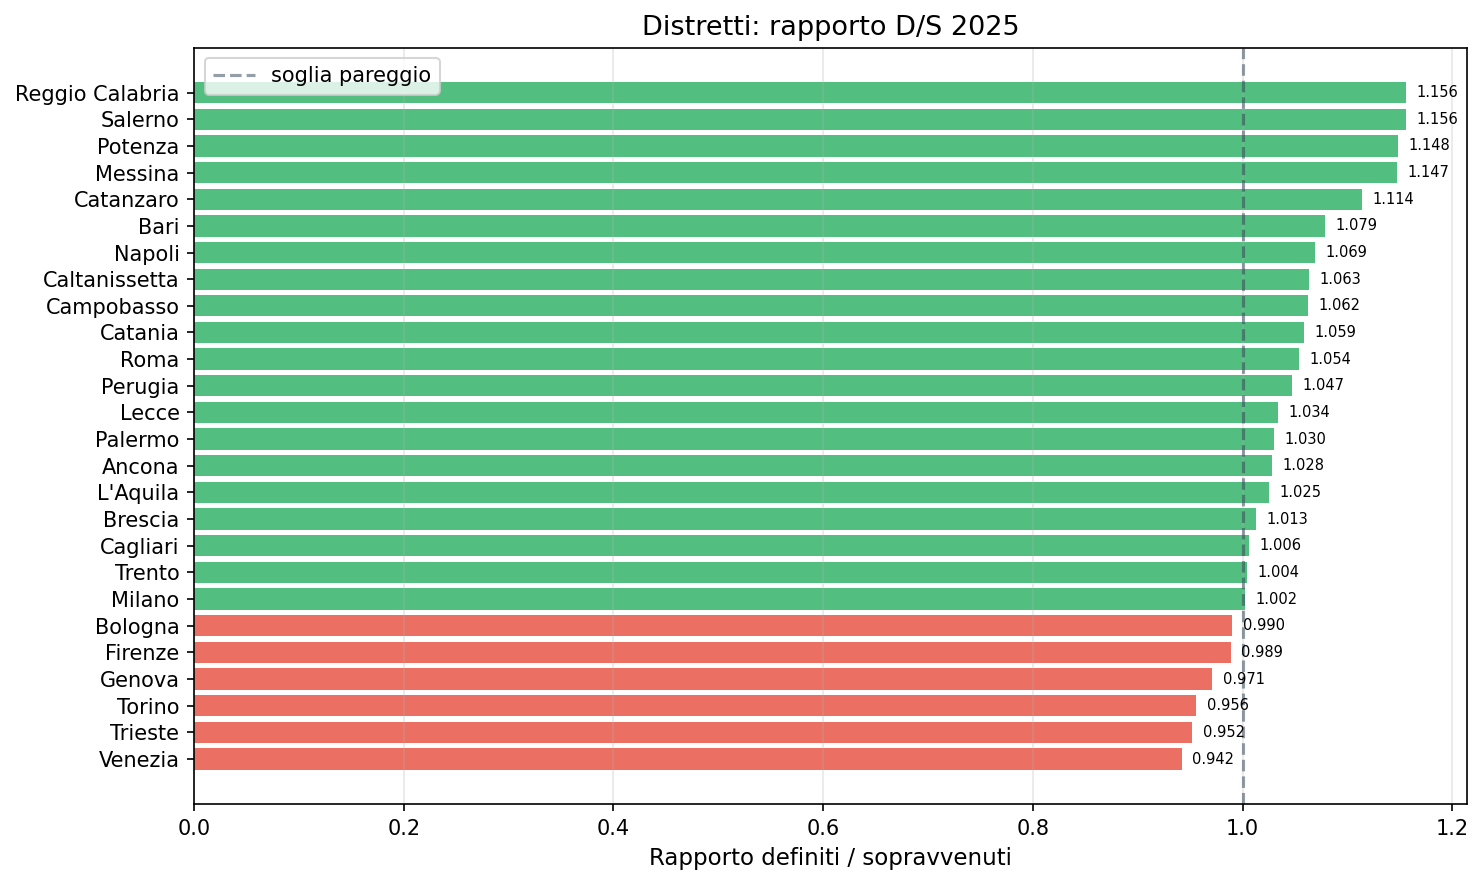

Salvato: figures/civile_distretti_2025.png


In [5]:
# Grafico distretti 2025
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = distretti.sort_values('rapporto_ds')
colors = ['#e74c3c' if r < 1 else '#27ae60' for r in plot_data['rapporto_ds']]
bars = ax.barh(plot_data['distretto'], plot_data['rapporto_ds'], color=colors, alpha=0.8)
ax.axvline(x=1.0, color='#2c3e50', linestyle='--', alpha=0.5, label='soglia pareggio')
ax.set_xlabel('Rapporto definiti / sopravvenuti', fontsize=11)
ax.set_title('Distretti: rapporto D/S 2025', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, plot_data['rapporto_ds']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('../figures/civile_distretti_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/civile_distretti_2025.png')


In [6]:
# 3. Evoluzione pendenti per distretto (2014 vs 2025)
pend_delta = con.execute(f"""
    SELECT a.distretto,
           CAST(a.pendenti_finali AS BIGINT) AS pend_2014,
           CAST(b.pendenti_finali AS BIGINT) AS pend_2025,
           ROUND((CAST(b.pendenti_finali AS DOUBLE) - CAST(a.pendenti_finali AS DOUBLE))
                 / NULLIF(CAST(a.pendenti_finali AS DOUBLE), 0) * 100, 1) AS var_pct
    FROM (SELECT distretto, SUM(pendenti_finali) AS pendenti_finali
          FROM read_parquet('{GCS}') WHERE anno = 2014 GROUP BY distretto) a
    JOIN (SELECT distretto, SUM(pendenti_finali) AS pendenti_finali
          FROM read_parquet('{GCS}') WHERE anno = 2025 GROUP BY distretto) b
    ON a.distretto = b.distretto
    ORDER BY var_pct DESC
""").fetchdf()

display(pend_delta)

print(f"Distretti in miglioramento: {len(pend_delta[pend_delta['var_pct'] < 0])} su {len(pend_delta)}")
print(f"Distretti in peggioramento: {len(pend_delta[pend_delta['var_pct'] > 0])} su {len(pend_delta)}")
print(f"Miglioramento maggiore: {pend_delta.iloc[-1]['distretto']} ({pend_delta.iloc[-1]['var_pct']:.1f}%)")


,distretto,pend_2014,pend_2025,var_pct
0,Trieste,35951,40208,12
1,Trento,22666,20925,-8
2,Torino,128267,110979,-14
3,Cagliari,93879,80971,-14
4,Caltanissetta,28381,24476,-14
5,Venezia,171694,143693,-16
6,Genova,69753,58076,-17
7,Palermo,128654,107215,-17
8,Brescia,95499,71747,-25
9,Bologna,148964,106908,-28


Distretti in miglioramento: 25 su 26
Distretti in peggioramento: 1 su 26
Miglioramento maggiore: Bari (-54.8%)


In [7]:
con.close()
print("Completato.")


Completato.
